In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Import the Pandas library
import pandas as pd

# load the data from google drive
df_path = "/content/drive/My Drive/SBD_CAPSTONE/merged_claim_failure_replacement_df.csv"  # Update with correct path

# Load the file using read_csv since it's a CSV file
df = pd.read_csv(df_path)

# Display the first few rows of the dataframe
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<ipython-input-4-bcbc6ab996ae>:11: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(df_path)


   Claim Number  Vendor Number Failure Part Series  tfidf_work_sum  \
0      20028686        10403.0                 757        1.716939   
1      20031456       725200.0                 925        2.713909   
2      20031965       136311.0                 725        2.180176   
3      20032034       546990.0                 YD3        1.935123   
4      20032289       725200.0                 925        1.675566   

   tfidf_work_avg  tfidf_diagnosis_sum  tfidf_diagnosis_avg  \
0        0.003434             1.697152             0.003394   
1        0.005428             2.707987             0.005416   
2        0.004360             1.402784             0.002806   
3        0.003870             1.407990             0.002816   
4        0.003351             2.358549             0.004717   

   tfidf_failure_part_descrip_sum  tfidf_failure_part_descrip_avg  \
0                        0.000000                        0.000000   
1                        2.995518                        0.005

In [5]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375364 entries, 0 to 375363
Data columns (total 35 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Claim Number                     375364 non-null  int64  
 1   Vendor Number                    375055 non-null  float64
 2   Failure Part Series              375364 non-null  object 
 3   tfidf_work_sum                   375364 non-null  float64
 4   tfidf_work_avg                   375364 non-null  float64
 5   tfidf_diagnosis_sum              375364 non-null  float64
 6   tfidf_diagnosis_avg              375364 non-null  float64
 7   tfidf_failure_part_descrip_sum   375364 non-null  float64
 8   tfidf_failure_part_descrip_avg   375364 non-null  float64
 9   work_performed_sentiment         375364 non-null  float64
 10  diagnosis_sentiment              375364 non-null  float64
 11  Failure Description              375364 non-null  object 
 12  Nu

In [6]:
# for failure date less than 2019 .....change the values to same as repair date

# Convert 'Failure Date' and 'Repair Date' to datetime objects

df['Failure Date'] = pd.to_datetime(df['Failure Date'])
df['Repair Date'] = pd.to_datetime(df['Repair Date'])

# Find rows where 'Failure Date' is before 2019
mask = df['Failure Date'] < pd.to_datetime('2019-01-01')

# Update 'Failure Date' with 'Repair Date' for those rows
df.loc[mask, 'Failure Date'] = df.loc[mask, 'Repair Date']

# Verify the changes
print(df.head())
print(df.info())


   Claim Number  Vendor Number Failure Part Series  tfidf_work_sum  \
0      20028686        10403.0                 757        1.716939   
1      20031456       725200.0                 925        2.713909   
2      20031965       136311.0                 725        2.180176   
3      20032034       546990.0                 YD3        1.935123   
4      20032289       725200.0                 925        1.675566   

   tfidf_work_avg  tfidf_diagnosis_sum  tfidf_diagnosis_avg  \
0        0.003434             1.697152             0.003394   
1        0.005428             2.707987             0.005416   
2        0.004360             1.402784             0.002806   
3        0.003870             1.407990             0.002816   
4        0.003351             2.358549             0.004717   

   tfidf_failure_part_descrip_sum  tfidf_failure_part_descrip_avg  \
0                        0.000000                        0.000000   
1                        2.995518                        0.005

In [7]:
# create a dataframe with only Failure Date, Claim number, Total Claim Dollars
df_new = df[['Failure Date', 'Claim Number', 'Total Claim Dollars']]
print(df_new.head())

  Failure Date  Claim Number  Total Claim Dollars
0   2020-04-01      20028686               218.98
1   2021-07-01      20031456               838.85
2   2022-07-01      20031965                61.61
3   2021-05-01      20032034                34.66
4   2019-01-08      20032289                83.85


In [8]:
import pandas as pd

# Convert 'Failure Date' to datetime format
df_new['Failure Date'] = pd.to_datetime(df_new['Failure Date'])

# Set 'Failure Date' as the index of the DataFrame
df_new.set_index('Failure Date', inplace=True)

# Resample the data to monthly frequency, counting unique 'Claim Number' and summing 'Total Claim Dollars'
monthly_aggregated_df = df_new.resample('M').agg({
    'Claim Number': 'nunique',  # Count unique claim numbers to get the monthly claim count
    'Total Claim Dollars': 'sum'  # Sum total claim dollars for each month
})

# Rename columns
monthly_aggregated_df.rename(columns={'Claim Number': 'Monthly Claim Count'}, inplace=True)

# Display the first few rows of the aggregated data
print(monthly_aggregated_df.head())


              Monthly Claim Count  Total Claim Dollars
Failure Date                                          
2019-01-31                     53             21203.17
2019-02-28                     52              7750.43
2019-03-31                     61             18468.28
2019-04-30                     75             25129.63
2019-05-31                    116             50089.24


<ipython-input-8-2b90aaaf90b7>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['Failure Date'] = pd.to_datetime(df_new['Failure Date'])
<ipython-input-8-2b90aaaf90b7>:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_aggregated_df = df_new.resample('M').agg({


In [9]:
# Define the date range
start_date = '2019-10-31'
end_date = '2024-10-31'

In [10]:
# Filter the data
monthly_aggregated_df = monthly_aggregated_df[(monthly_aggregated_df.index >= start_date) & (monthly_aggregated_df.index <= end_date)]

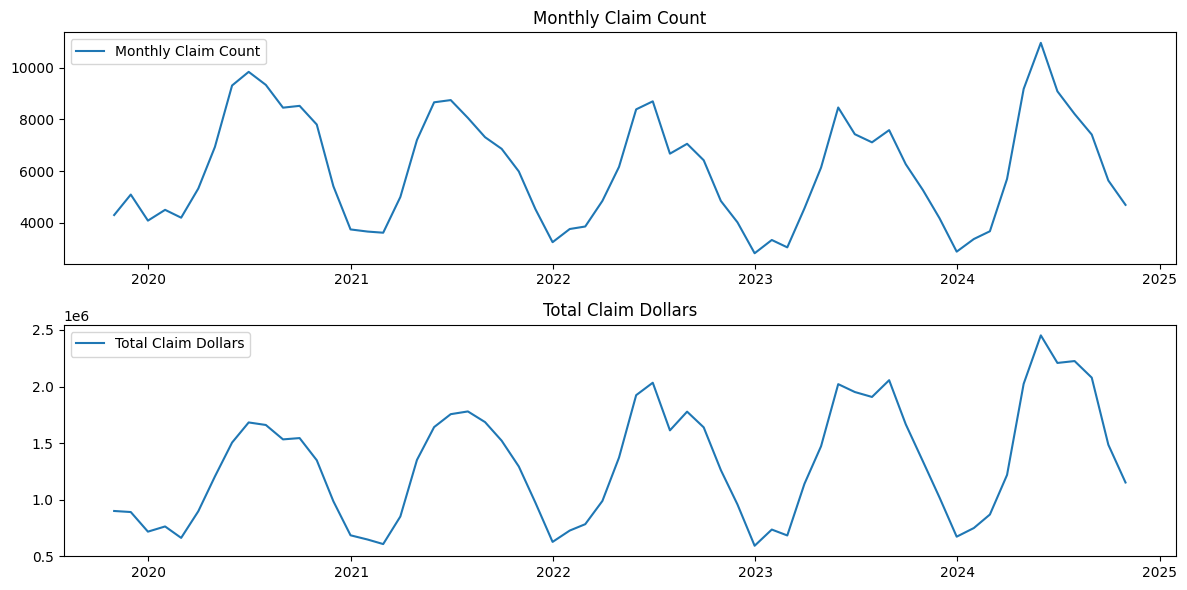

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(monthly_aggregated_df['Monthly Claim Count'], label='Monthly Claim Count')
plt.title('Monthly Claim Count')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(monthly_aggregated_df['Total Claim Dollars'], label='Total Claim Dollars')
plt.title('Total Claim Dollars')
plt.legend()

plt.tight_layout()
plt.show()


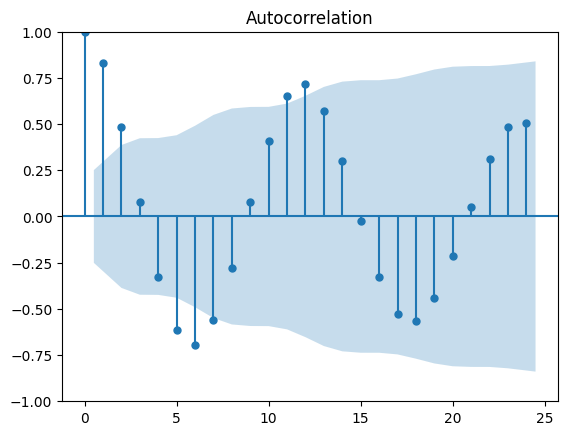

In [12]:
# check acf plot
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(monthly_aggregated_df['Total Claim Dollars'], lags=24)  # Check up to 24 lags
plt.show()


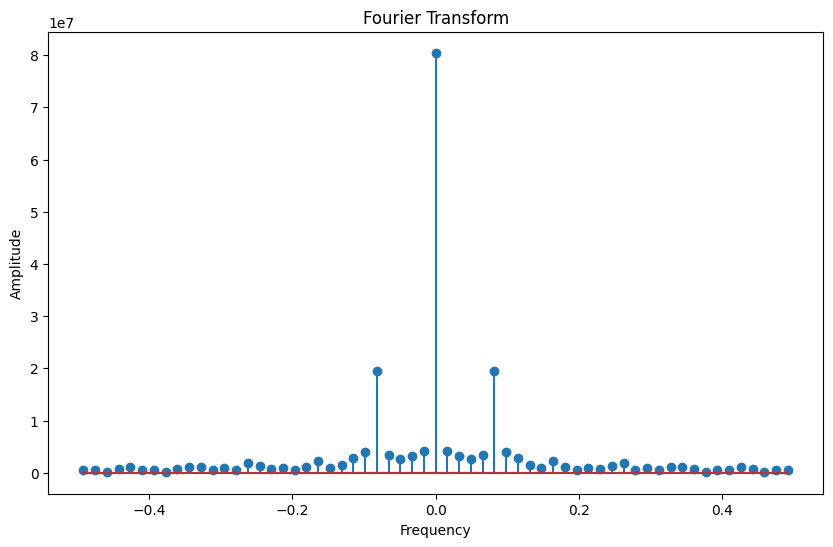

In [13]:
import numpy as np

# Perform a Fourier transform
data_fft = np.fft.fft(monthly_aggregated_df['Total Claim Dollars'])

# Get frequencies and magnitudes
frequencies = np.fft.fftfreq(len(data_fft), d=1)  # d is the sampling period, 1 if your data is normalized to 1 unit per sample
amplitudes = np.abs(data_fft)

plt.figure(figsize=(10, 6))
plt.stem(frequencies, amplitudes)
plt.title('Fourier Transform')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.show()


In [14]:
# tail
monthly_aggregated_df.tail()

,Monthly Claim Count,Total Claim Dollars
Failure Date,,
2024-06-30,9080,2208514.08
2024-07-31,8205,2225202.09
2024-08-31,7410,2078412.88
2024-09-30,5633,1484610.91
2024-10-31,4692,1150802.96


In [15]:
# head
monthly_aggregated_df.head()

,Monthly Claim Count,Total Claim Dollars
Failure Date,,
2019-10-31,4299,898874.48
2019-11-30,5090,889546.83
2019-12-31,4083,716004.09
2020-01-31,4500,761975.22
2020-02-29,4197,660866.24


In [16]:
# check all rows
print(monthly_aggregated_df)

              Monthly Claim Count  Total Claim Dollars
Failure Date                                          
2019-10-31                   4299            898874.48
2019-11-30                   5090            889546.83
2019-12-31                   4083            716004.09
2020-01-31                   4500            761975.22
2020-02-29                   4197            660866.24
...                           ...                  ...
2024-06-30                   9080           2208514.08
2024-07-31                   8205           2225202.09
2024-08-31                   7410           2078412.88
2024-09-30                   5633           1484610.91
2024-10-31                   4692           1150802.96

[61 rows x 2 columns]


In [17]:
# # Split the data into train and test sets

train = monthly_aggregated_df[:'2023-10-31']
test = monthly_aggregated_df['2023-11-01':]


In [ ]:
pip install pmdarima


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 20.7 MB/s eta 0:00:00


## Simple Arima Model

In [18]:
start_date = '2019-10-31'
end_date = '2023-10-31'
train_data = train[(train.index >= start_date) & (train.index <= end_date)]

In [ ]:
import pmdarima as pm

# Fit ARIMA model for Total Claim Dollars

model_dollars = pm.auto_arima(train_data['Total Claim Dollars'],
                              seasonal=True,
                              m=12,
                              stepwise=True,
                              suppress_warnings=True,
                              error_action='ignore')


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
model_dollars.summary()

In [ ]:
# Future dates for forecasting
future_dates = pd.date_range(start=test.index[0], periods=len(test), freq='M')

# Forecast for Total Claim Dollars
forecast_dollars = model_dollars.predict(n_periods=len(test))

In [ ]:
# Plotting the forecasts against the actual test data

plt.figure(figsize=(14, 7))
plt.subplot(2, 1, 1)
plt.plot(train_data['Total Claim Dollars'], label='Training Data (Dollars)')
plt.plot(test['Total Claim Dollars'], label='Test Data (Dollars)', color='orange')
plt.plot(future_dates, forecast_dollars, label='Forecasted Data (Dollars)', color='red')
plt.title('Forecast vs Actuals for Total Claim Dollars')
plt.legend()

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import pandas as pd

# Assuming future_dates, forecast_dollars, and forecast_count are already defined and align with test data dates

# Function to format the tick marks as millions
def millions_formatter(x, pos):
    return '%1.1fM' % (x * 1e-6)

plt.figure(figsize=(14, 14))

# Plotting the forecast against actual data for Total Claim Dollars
ax1 = plt.subplot(2, 1, 1)
ax1.plot(test.index, test['Total Claim Dollars'], label='Actual Test Data (Dollars)', color='orange', marker='o')
ax1.plot(test.index, forecast_dollars, label='Forecasted Data (Dollars)', color='red', marker='x')
ax1.set_title('Forecast vs Actuals for Total Claim Dollars')
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Claim Dollars (in millions)')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(millions_formatter))  # Apply custom formatter
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 4, 7, 10)))  # Quarterly ticks
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Year-Month format
ax1.grid(True)
ax1.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels to avoid overlap


plt.tight_layout()
plt.show()


In [ ]:
# prompt: calculate rmse, mse, r square for train and test data

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calculate RMSE, MSE, and R-squared for Total Claim Dollars
rmse_dollars = np.sqrt(mean_squared_error(test['Total Claim Dollars'], forecast_dollars))
mse_dollars = mean_squared_error(test['Total Claim Dollars'], forecast_dollars)
r2_dollars = r2_score(test['Total Claim Dollars'], forecast_dollars)

print(f"Total Claim Dollars - RMSE on Test Data : {rmse_dollars}")
print(f"Total Claim Dollars - MSE on Test Data : {mse_dollars}")
print(f"Total Claim Dollars - R-squared on Test Data: {r2_dollars}")


In [ ]:
# Assuming 'future_dates' will start immediately after the last date in your test data
last_test_date = test.index[-1]

# Generate future dates for the next 24 months
extended_future_dates = pd.date_range(start=last_test_date + pd.DateOffset(months=1), periods=24, freq='M')


In [ ]:
# Forecast for Total Claim Dollars for the next 24 months
extended_forecast_dollars = model_dollars.predict(n_periods=24)


In [ ]:
# extended_forecast_dollars in millions
extended_forecast_dollars = extended_forecast_dollars / 1000000

# show as predictied heading
print(extended_forecast_dollars)

In [ ]:
# show month and predicted in millions as header

# Create a DataFrame for the extended forecast
extended_forecast_df = pd.DataFrame({
    'Month': extended_future_dates,
    'Predicted (Millions)': extended_forecast_dollars
})

# Set 'Month' as the index
extended_forecast_df = extended_forecast_df.set_index('Month')

# Display the DataFrame with the desired headers
extended_forecast_df


## Prophet

In [30]:
# Install Prophet if not installed
!pip install prophet

# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import matplotlib.dates as mdates


In [31]:
# Prepare DataFrames for Prophet (Train Data)
train_dollars = train[['Total Claim Dollars']].reset_index()
train_dollars.columns = ['ds', 'y']

# Prepare DataFrames for Prophet (Test Data)
test_dollars = test[['Total Claim Dollars']].reset_index()
test_dollars.columns = ['ds', 'y']


In [32]:
# Prophet model for Total Claim Dollars
model_dollars = Prophet(yearly_seasonality=True, daily_seasonality=False)
model_dollars.fit(train_dollars)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmprd2kka1t/6l31fmxw.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmprd2kka1t/64cdv9ub.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=80029', 'data', 'file=/tmp/tmprd2kka1t/6l31fmxw.json', 'init=/tmp/tmprd2kka1t/64cdv9ub.json', 'output', 'file=/tmp/tmprd2kka1t/prophet_model42lxlgb6/prophet_model-20250419222823.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
22:28:23 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:28:24 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [33]:
# Create future DataFrame with test dates
future_test_dollars = test_dollars[['ds']]

# Predict on test data
forecast_test_dollars = model_dollars.predict(future_test_dollars)

# Extract only the required columns for comparison
forecast_test_dollars = forecast_test_dollars[['ds', 'yhat']].set_index('ds')

# Merge with actual test data for comparison
test_dollars = test_dollars.set_index('ds')

comparison_dollars = test_dollars.join(forecast_test_dollars)

# Rename column
comparison_dollars.columns = ['Actual', 'Predicted']

# Display results
print(comparison_dollars)


                Actual     Predicted
ds                                  
2023-11-30  1018023.40  1.161065e+06
2023-12-31   671495.46  9.119862e+05
2024-01-31   747979.57  1.000281e+06
2024-02-29   867442.10  9.647701e+05
2024-03-31  1217978.72  1.186787e+06
2024-04-30  2023676.42  1.592782e+06
2024-05-31  2452576.88  1.869565e+06
2024-06-30  2208514.08  2.055236e+06
2024-07-31  2225202.09  1.994752e+06
2024-08-31  2078412.88  1.828299e+06
2024-09-30  1484610.91  1.807617e+06
2024-10-31  1150802.96  1.604017e+06


In [34]:
# import libraries
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calculate RMSE, MSE, and R-squared for Total Claim Dollars using Prophet predictions
rmse_dollars_prophet = np.sqrt(mean_squared_error(comparison_dollars['Actual'], comparison_dollars['Predicted']))
mse_dollars_prophet = mean_squared_error(comparison_dollars['Actual'], comparison_dollars['Predicted'])
r2_dollars_prophet = r2_score(comparison_dollars['Actual'], comparison_dollars['Predicted'])

print(f"Total Claim Dollars (Prophet) - RMSE on Test Data : {rmse_dollars_prophet}")
print(f"Total Claim Dollars (Prophet) - MSE on Test Data : {mse_dollars_prophet}")
print(f"Total Claim Dollars (Prophet) - R-squared on Test Data: {r2_dollars_prophet}")


Total Claim Dollars (Prophet) - RMSE on Test Data : 306440.10075669765
Total Claim Dollars (Prophet) - MSE on Test Data : 93905535351.77501
Total Claim Dollars (Prophet) - R-squared on Test Data: 0.7565329495855428


In [35]:
# Create future DataFrame for the next 24 months (Nov 2024 - Nov 2026)
future_dates = model_dollars.make_future_dataframe(periods=24, freq='M')

# Predict future values
future_forecast_dollars = model_dollars.predict(future_dates)

# Extract relevant columns
future_forecast_dollars = future_forecast_dollars[['ds', 'yhat']].set_index('ds')


/usr/local/lib/python3.11/dist-packages/prophet/forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


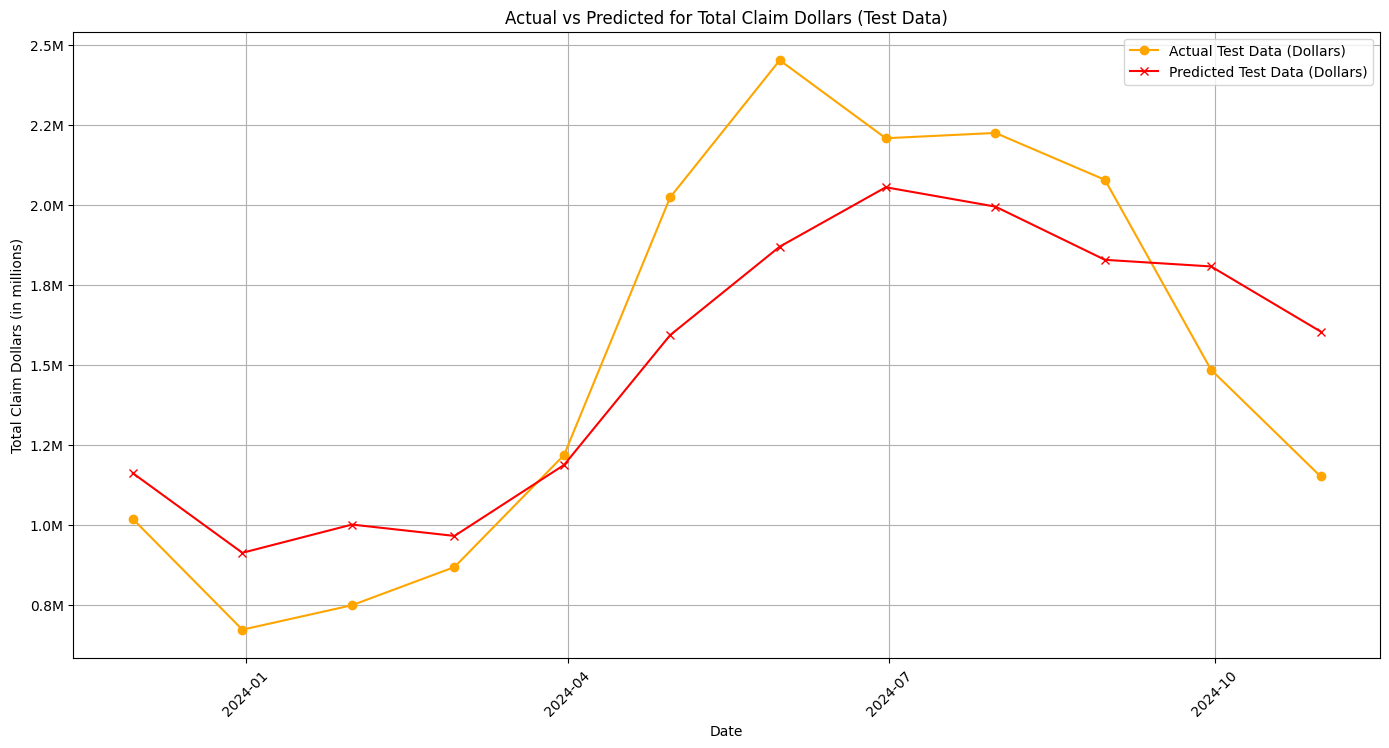

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from sklearn.metrics import mean_squared_error, r2_score

# Function to format y-axis as millions
def millions_formatter(x, pos):
    return '%1.1fM' % (x * 1e-6)

# Actual vs. Predicted on Test Data
plt.figure(figsize=(14, 14))

# Total Claim Dollars Actual vs Predicted
ax1 = plt.subplot(2, 1, 1)
ax1.plot(comparison_dollars.index, comparison_dollars['Actual'], label='Actual Test Data (Dollars)', color='orange', marker='o')
ax1.plot(comparison_dollars.index, comparison_dollars['Predicted'], label='Predicted Test Data (Dollars)', color='red', marker='x')
ax1.set_title('Actual vs Predicted for Total Claim Dollars (Test Data)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Claim Dollars (in millions)')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(millions_formatter))  # Apply custom formatter
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 4, 7, 10)))  # Quarterly ticks
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Year-Month format
ax1.legend()
ax1.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



### SARIMA WITH EXOGENOUS

In [37]:
import pandas as pd


# Convert 'Failure Date' to datetime format
df['Failure Date'] = pd.to_datetime(df['Failure Date'])

# Set 'Failure Date' as index and resample monthly
monthly_aggregated_additional_regressors_df = df.resample('M', on='Failure Date').agg({
    'Claim Number': 'count',
    'tfidf_work_sum': 'sum',
    'tfidf_diagnosis_sum': 'sum',
    'tfidf_failure_part_descrip_avg': 'sum',
    'work_performed_sentiment': 'sum',
    'diagnosis_sentiment': 'sum',
    'Number of Failure Parts': 'sum',
    'Number of Replacement Parts': 'sum',
    'Part Quantity': 'sum',
    'Paid Labor Hours': 'sum',
    'Total Claim Dollars': 'sum'
}).reset_index()




<ipython-input-37-5eb1e4936666>:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_aggregated_additional_regressors_df = df.resample('M', on='Failure Date').agg({


In [38]:
# info
monthly_aggregated_additional_regressors_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Failure Date                    71 non-null     datetime64[ns]
 1   Claim Number                    71 non-null     int64         
 2   tfidf_work_sum                  71 non-null     float64       
 3   tfidf_diagnosis_sum             71 non-null     float64       
 4   tfidf_failure_part_descrip_avg  71 non-null     float64       
 5   work_performed_sentiment        71 non-null     float64       
 6   diagnosis_sentiment             71 non-null     float64       
 7   Number of Failure Parts         71 non-null     int64         
 8   Number of Replacement Parts     71 non-null     int64         
 9   Part Quantity                   71 non-null     int64         
 10  Paid Labor Hours                71 non-null     float64       
 11  Total Cl

In [39]:
# check head
monthly_aggregated_additional_regressors_df.head()

,Failure Date,Claim Number,tfidf_work_sum,tfidf_diagnosis_sum,tfidf_failure_part_descrip_avg,work_performed_sentiment,diagnosis_sentiment,Number of Failure Parts,Number of Replacement Parts,Part Quantity,Paid Labor Hours,Total Claim Dollars
0,2019-01-31,53,101.420573,131.224121,0.117211,1.037563,-3.044027,56,153,190,68.54,21203.17
1,2019-02-28,52,84.524029,108.885602,0.112185,0.488182,-1.441064,57,99,107,42.11,7750.43
2,2019-03-31,61,116.902185,154.756142,0.102253,0.544372,0.753842,66,135,160,78.88,18468.28
3,2019-04-30,75,137.906205,190.413679,0.150073,0.435011,-6.777016,77,168,227,116.11,25129.63
4,2019-05-31,116,218.814032,314.676170,0.229905,1.497821,-5.934300,124,256,305,171.68,50089.24


In [41]:
# Define the date range
start_date = '2019-10-31'
end_date = '2024-10-31'

In [42]:
# Filter the data
# Convert start_date and end_date to datetime objects for comparison
start_date = pd.to_datetime(start_date)
end_date = pd.to_datetime(end_date)

# Assuming 'Failure Date' is the column you want to filter on
monthly_aggregated_additional_regressors_df = monthly_aggregated_additional_regressors_df[
    (monthly_aggregated_additional_regressors_df['Failure Date'] >= start_date) &
    (monthly_aggregated_additional_regressors_df['Failure Date'] <= end_date)
]

In [43]:
# info
monthly_aggregated_additional_regressors_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61 entries, 9 to 69
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Failure Date                    61 non-null     datetime64[ns]
 1   Claim Number                    61 non-null     int64         
 2   tfidf_work_sum                  61 non-null     float64       
 3   tfidf_diagnosis_sum             61 non-null     float64       
 4   tfidf_failure_part_descrip_avg  61 non-null     float64       
 5   work_performed_sentiment        61 non-null     float64       
 6   diagnosis_sentiment             61 non-null     float64       
 7   Number of Failure Parts         61 non-null     int64         
 8   Number of Replacement Parts     61 non-null     int64         
 9   Part Quantity                   61 non-null     int64         
 10  Paid Labor Hours                61 non-null     float64       
 11  Total Claim D

In [44]:
# Splitting the data into train and test sets using date-based filtering
train = monthly_aggregated_additional_regressors_df[monthly_aggregated_additional_regressors_df['Failure Date'] <= '2023-10-31']
test = monthly_aggregated_additional_regressors_df[monthly_aggregated_additional_regressors_df['Failure Date'] > '2023-10-31']


# Define target variable (y) and exogenous variables (X)
y_train = train['Total Claim Dollars']
X_train = train.drop(columns=['Failure Date', 'Total Claim Dollars'])

y_test = test['Total Claim Dollars']
X_test = test.drop(columns=['Failure Date', 'Total Claim Dollars'])

# Fitting SARIMAX model with exogenous variables
import statsmodels.api as sm

sarimax_model = sm.tsa.SARIMAX(y_train, exog=X_train, order=(1,1,1), seasonal_order=(1,1,1,12),
                               enforce_stationarity=False, enforce_invertibility=False)
sarimax_results = sarimax_model.fit()

# Forecast on test data
y_pred = sarimax_results.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1, exog=X_test)

# Evaluate model performance
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display evaluation metrics
evaluation_metrics = {
    "Mean Squared Error (MSE)": mse,
    "Root Mean Squared Error (RMSE)": rmse,
    "R-Squared": r2
}

evaluation_metrics


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Chec

{'Mean Squared Error (MSE)': 16653246348.27974,
 'Root Mean Squared Error (RMSE)': np.float64(129047.45773660069),
 'R-Squared': 0.9568234529194412}

In [45]:
# In-sample predictions on the training data
y_train_pred = sarimax_results.fittedvalues


# Evaluate model performance on training data
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

# Display train evaluation metrics
train_evaluation_metrics = {
    "Mean Squared Error (MSE)": train_mse,
    "Root Mean Squared Error (RMSE)": train_rmse,
    "R-Squared": train_r2
}

train_evaluation_metrics


{'Mean Squared Error (MSE)': 3343650897.3166323,
 'Root Mean Squared Error (RMSE)': np.float64(57824.3106082263),
 'R-Squared': 0.9841043787640551}

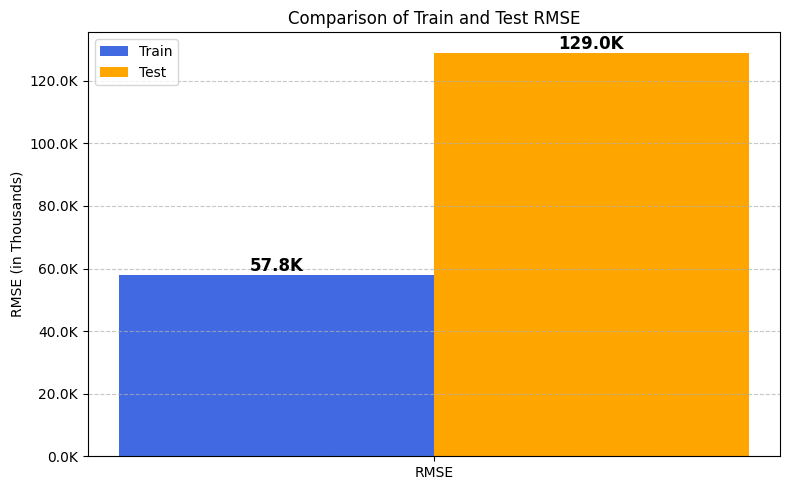

In [46]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Extract RMSE values from the dictionaries
train_rmse = train_evaluation_metrics["Root Mean Squared Error (RMSE)"]
test_rmse = evaluation_metrics["Root Mean Squared Error (RMSE)"]

# Prepare data for plotting
metrics = ['RMSE']
train_values = [train_rmse]
test_values = [test_rmse]

# Create improved bar chart
plt.figure(figsize=(8, 5))
x = range(len(metrics))

bars1 = plt.bar(x, train_values, width=0.4, label="Train", align="center", color='royalblue')
bars2 = plt.bar([i + 0.4 for i in x], test_values, width=0.4, label="Test", align="center", color='orange')

# Labels and title
plt.xticks([i + 0.2 for i in x], metrics)
plt.ylabel("RMSE (in Thousands)")
plt.title("Comparison of Train and Test RMSE")

# Format y-axis in thousands (K)
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x / 1e3:.1f}K'))

# Add value labels on top of bars
for bar in bars1 + bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height / 1e3:.1f}K', ha='center', va='bottom',
             fontsize=12, fontweight='bold')

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [47]:
# Creating a DataFrame to compare actual vs predicted values for the test set
actual_vs_predicted_df = pd.DataFrame({
    "Date": test["Failure Date"],
    "Actual Total Claim Dollars": y_test.values,
    "Predicted Total Claim Dollars": y_pred.values
})

# Convert values to millions for better readability
actual_vs_predicted_df["Actual Total Claim Dollars"] /= 1e6
actual_vs_predicted_df["Predicted Total Claim Dollars"] /= 1e6

# print
actual_vs_predicted_df

,Date,Actual Total Claim Dollars,Predicted Total Claim Dollars
58,2023-11-30,1.018023,1.131242
59,2023-12-31,0.671495,0.720971
60,2024-01-31,0.747980,0.852085
61,2024-02-29,0.867442,0.917279
62,2024-03-31,1.217979,1.439539
63,2024-04-30,2.023676,2.302554
64,2024-05-31,2.452577,2.607458
65,2024-06-30,2.208514,2.306461
66,2024-07-31,2.225202,2.165561
67,2024-08-31,2.078413,2.070298


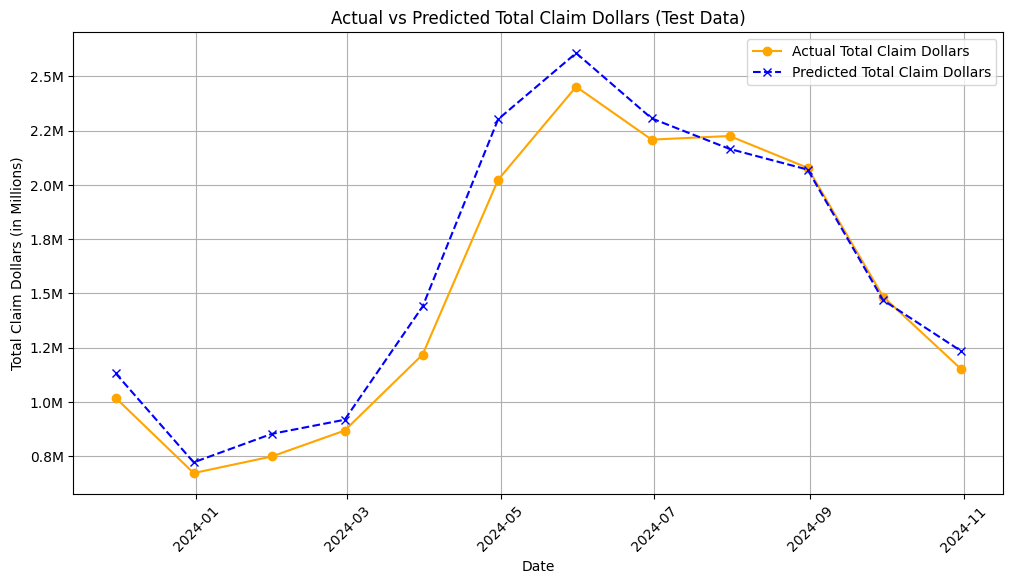

In [48]:
# import plt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

# Create a figure and axis
# Plot Actual vs Predicted for Test Data
plt.figure(figsize=(12, 6))

plt.plot(test["Failure Date"], y_test, marker='o', linestyle='-', color='orange', label="Actual Total Claim Dollars")
plt.plot(test["Failure Date"], y_pred, marker='x', linestyle='--', color='blue', label="Predicted Total Claim Dollars")

plt.title("Actual vs Predicted Total Claim Dollars (Test Data)")
plt.xlabel("Date")
plt.ylabel("Total Claim Dollars (in Millions)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

# Format y-axis to show values in millions
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x * 1e-6:.1f}M'))

plt.show()


In [49]:
monthly_aggregated_additional_regressors_df.tail(20)

,Failure Date,Claim Number,tfidf_work_sum,tfidf_diagnosis_sum,tfidf_failure_part_descrip_avg,work_performed_sentiment,diagnosis_sentiment,Number of Failure Parts,Number of Replacement Parts,Part Quantity,Paid Labor Hours,Total Claim Dollars
50,2023-03-31,4557,9460.647175,11823.402952,9.962921,69.132779,-190.796223,4821,8275,9906,4291.81,1139126.29
51,2023-04-30,6134,12507.898559,16013.978864,14.173221,84.500460,-278.672522,6396,11276,13123,5550.96,1471645.32
52,2023-05-31,8456,17054.720944,21207.503717,20.816971,113.579984,-315.838969,8824,15937,18451,7309.40,2021014.25
53,2023-06-30,7423,15247.861355,19102.514646,17.715420,90.160670,-275.294612,7803,14473,17000,6818.36,1951328.55
54,2023-07-31,7109,14884.322339,18096.421704,17.137328,101.069631,-281.646913,7555,13648,15928,6709.22,1907689.15
55,2023-08-31,7581,15907.669427,19548.603515,17.864353,103.724001,-360.119579,8017,14661,17421,6982.92,2055886.84
56,2023-09-30,6264,13400.010492,16712.716569,14.701016,110.944856,-269.106991,6606,11664,13607,5907.01,1665979.88
57,2023-10-31,5265,11397.425619,13943.849030,11.929691,127.982835,-250.679414,5600,9602,11507,5015.26,1338054.98
58,2023-11-30,4176,9120.824966,10638.084403,9.293035,75.641515,-179.345392,4473,7703,9090,3909.49,1018023.40
59,2023-12-31,2884,6170.351909,6868.772769,6.373174,70.455945,-106.594310,3056,5416,6263,2515.76,671495.46


## Loading Future values of Exogenous Variables

We have used 2 techniques to future forecast the exogenous varibles

1. Developed seperate models for each of the variable and find the future forecast values

2. Use the last one year data values as the future forecast values

We are using second method as we are able to find out second method (using previous year values is the best option as we are able to get better forecasts)

In [104]:
from google.colab import drive
drive.mount('/content/drive')

# Import the Pandas library
import pandas as pd

# Assuming the file is stored on Google Drive and is an xlsx file
future_forecast_df_exogenous_path = "/content/drive/My Drive/SBD_CAPSTONE/exogenous_variables_2025.csv"

# Load the file using read_excel since it's an xlsx file
future_forecast_df_exogenous = pd.read_csv(future_forecast_df_exogenous_path)

# Display the first few rows of the dataframe
print(future_forecast_df_exogenous.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Failure Date  Claim Number  tfidf_work_sum  tfidf_diagnosis_sum  \
0   11/30/2024          4176     9120.824966         10638.084400   
1   12/31/2024          2884     6170.351909          6868.772769   
2    1/31/2025          3372     7603.869127          8918.116085   
3    2/29/2025          3672     8087.480017          9300.733864   
4    3/31/2025          5696    12568.465670         13610.474830   

   tfidf_failure_part_descrip_avg  work_performed_sentiment  \
0                        9.293035                 75.641515   
1                        6.373174                 70.455945   
2                        7.344738                 79.340561   
3                        8.868950                 49.543928   
4                       14.013155                 68.214103   

   diagnosis_sentiment  Number of Failure Parts  Number of Replacement Parts 

In [105]:
future_forecast_df_exogenous.head(100)

,Failure Date,Claim Number,tfidf_work_sum,tfidf_diagnosis_sum,tfidf_failure_part_descrip_avg,work_performed_sentiment,diagnosis_sentiment,Number of Failure Parts,Number of Replacement Parts,Part Quantity,Paid Labor Hours,Total Claim Dollars
0,11/30/2024,4176,9120.824966,10638.084400,9.293035,75.641515,-179.345392,4473,7703,9090,3909.49,1018023.40
1,12/31/2024,2884,6170.351909,6868.772769,6.373174,70.455945,-106.594310,3056,5416,6263,2515.76,671495.46
2,1/31/2025,3372,7603.869127,8918.116085,7.344738,79.340561,-136.123261,3648,6400,7477,3069.48,747979.57
3,2/29/2025,3672,8087.480017,9300.733864,8.868950,49.543928,-167.901921,3947,7294,8508,3008.86,867442.10
4,3/31/2025,5696,12568.465670,13610.474830,14.013155,68.214103,-264.180911,6075,11227,12772,4251.18,1217978.72
5,4/30/2025,9172,19256.396880,20144.092150,24.275668,111.191544,-401.748305,9638,17973,20038,6463.82,2023676.42
6,5/31/2025,10954,22322.969920,24514.632440,29.935837,164.403496,-447.778996,11376,20762,23180,7806.91,2452576.88
7,6/30/2025,9080,19061.063950,21344.847390,23.553278,174.736521,-368.423957,9482,17111,19526,7310.77,2208514.08
8,7/31/2025,8205,17430.281570,19478.477450,19.955024,138.365480,-336.717033,8589,15137,17447,7076.46,2225202.09
9,8/31/2025,7410,16205.174170,17717.284620,18.156301,153.879511,-317.446076,7811,13488,15841,6624.81,2078412.88


In [84]:
# show head
future_forecast_df_exogenous.head()

,Failure Date,Claim Number,tfidf_work_sum,tfidf_diagnosis_sum,tfidf_failure_part_descrip_avg,work_performed_sentiment,diagnosis_sentiment,Number of Failure Parts,Number of Replacement Parts,Part Quantity,Paid Labor Hours
0,2024-11-30,3941.783197,9191.244579,9407.386288,8.756591,110.134224,-214.198983,4166.788859,6366.718764,7617.092990,3651.551978
1,2024-12-31,2684.723225,6831.038991,6386.674689,5.724282,103.339633,-170.457890,2865.318601,4948.526742,6133.805503,2550.334649
2,2025-01-31,3108.433227,7994.289602,7426.103404,6.293428,109.081691,-193.523760,3342.912674,5100.242095,6243.019437,3116.415938
3,2025-02-28,2991.687725,7594.407485,6668.438766,6.405793,101.722939,-194.482239,3175.244859,5099.369457,6418.952357,2905.629203
4,2025-03-31,4272.750160,10240.947154,10091.563520,9.324339,113.743218,-274.551845,4543.209004,7380.433375,9086.003925,4108.269412


In [106]:
import pandas as pd
import statsmodels.api as sm

# Combine the target and exogenous features from the full dataset
y_combined = pd.concat([y_train, y_test])
X_combined = pd.concat([X_train, X_test])

# Fit SARIMA model again using exogenous variables
sarima_model_combined = sm.tsa.SARIMAX(
    y_combined,
    exog=X_combined,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_results_combined = sarima_model_combined.fit()



# Now generate the future dates
last_date = test['Failure Date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq='M')

# Check if future_exog_df has the correct shape (same number of columns as X_combined)
if future_forecast_df_exogenous.shape[1] == X_combined.shape[1] and future_forecast_df_exogenous.shape[0] == 12:
    # Forecast Total Claim Dollars using future exogenous variables
    future_forecast_combined = sarima_results_combined.forecast(steps=12, exog=future_forecast_df_exogenous)

    # Format the result into a DataFrame
    future_forecast_df_combined = pd.DataFrame({
        "Date": future_dates,
        "Forecasted Total Claim Dollars": future_forecast_combined
    })

    # Convert to millions (if applicable)
    future_forecast_df_combined["Forecasted Total Claim Dollars"] /= 1e6

    # Show result
    print(future_forecast_df_combined)
else:
    print("Error: The forecasted exogenous variables do not match the expected shape.")


Error: The forecasted exogenous variables do not match the expected shape.


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
<ipython-input-106-bf9bf66da8ba>:25: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq='M')


In [107]:
if future_forecast_df_exogenous.shape[1] != X_combined.shape[1]:
    print(f"Error: The number of columns in future_forecast_df_exogenous ({future_forecast_df_exogenous.shape[1]}) "
          f"does not match the number of columns in X_combined ({X_combined.shape[1]}).")
if future_forecast_df_exogenous.shape[0] != 24:
    print(f"Error: The number of rows in future_forecast_df_exogenous ({future_forecast_df_exogenous.shape[0]}) "
          "does not match the number of forecast periods.")


Error: The number of columns in future_forecast_df_exogenous (12) does not match the number of columns in X_combined (10).
Error: The number of rows in future_forecast_df_exogenous (12) does not match the number of forecast periods.


In [108]:
# Check the column names of X_combined and future_forecast_df_exogenous
print("Columns in X_combined:", X_combined.columns)
print("Columns in future_forecast_df_exogenous:", future_forecast_df_exogenous.columns)


# Ensure the columns of future_forecast_df_exogenous match X_combined
future_forecast_df_exogenous = future_forecast_df_exogenous[X_combined.columns]

# After ensuring column consistency, set the correct index for future_forecast_df_exogenous
future_forecast_df_exogenous['Date'] = future_dates
future_forecast_df_exogenous.index = pd.to_datetime(future_forecast_df_exogenous['Date'])
future_forecast_df_exogenous = future_forecast_df_exogenous.drop(columns='Date')

# Now forecast Total Claim Dollars using the corrected exogenous variables
future_forecast_combined = sarima_results_combined.forecast(steps=12, exog=future_forecast_df_exogenous)

# Format the result
future_forecast_df_combined = pd.DataFrame({
    "Date": future_dates,
    "Forecasted Total Claim Dollars": future_forecast_combined
})

# Convert to millions (if applicable)
future_forecast_df_combined["Forecasted Total Claim Dollars"] /= 1e6

# Show result
print(future_forecast_df_combined)


Columns in X_combined: Index(['Claim Number', 'tfidf_work_sum', 'tfidf_diagnosis_sum',
       'tfidf_failure_part_descrip_avg', 'work_performed_sentiment',
       'diagnosis_sentiment', 'Number of Failure Parts',
       'Number of Replacement Parts', 'Part Quantity', 'Paid Labor Hours'],
      dtype='object')
Columns in future_forecast_df_exogenous: Index(['Failure Date', 'Claim Number', 'tfidf_work_sum', 'tfidf_diagnosis_sum',
       'tfidf_failure_part_descrip_avg', 'work_performed_sentiment',
       'diagnosis_sentiment', 'Number of Failure Parts',
       'Number of Replacement Parts', 'Part Quantity', 'Paid Labor Hours',
       'Total Claim Dollars'],
      dtype='object')
         Date  Forecasted Total Claim Dollars
61 2024-11-30                        1.059208
62 2024-12-31                        0.659802
63 2025-01-31                        0.772807
64 2025-02-28                        0.835781
65 2025-03-31                        1.289790
66 2025-04-30                        2

<ipython-input-108-0c1c0f56596e>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  future_forecast_df_exogenous['Date'] = future_dates
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [109]:
future_forecast_df_combined

,Date,Forecasted Total Claim Dollars
61,2024-11-30,1.059208
62,2024-12-31,0.659802
63,2025-01-31,0.772807
64,2025-02-28,0.835781
65,2025-03-31,1.289790
66,2025-04-30,2.032134
67,2025-05-31,2.439435
68,2025-06-30,2.218779
69,2025-07-31,2.160182
70,2025-08-31,2.075605


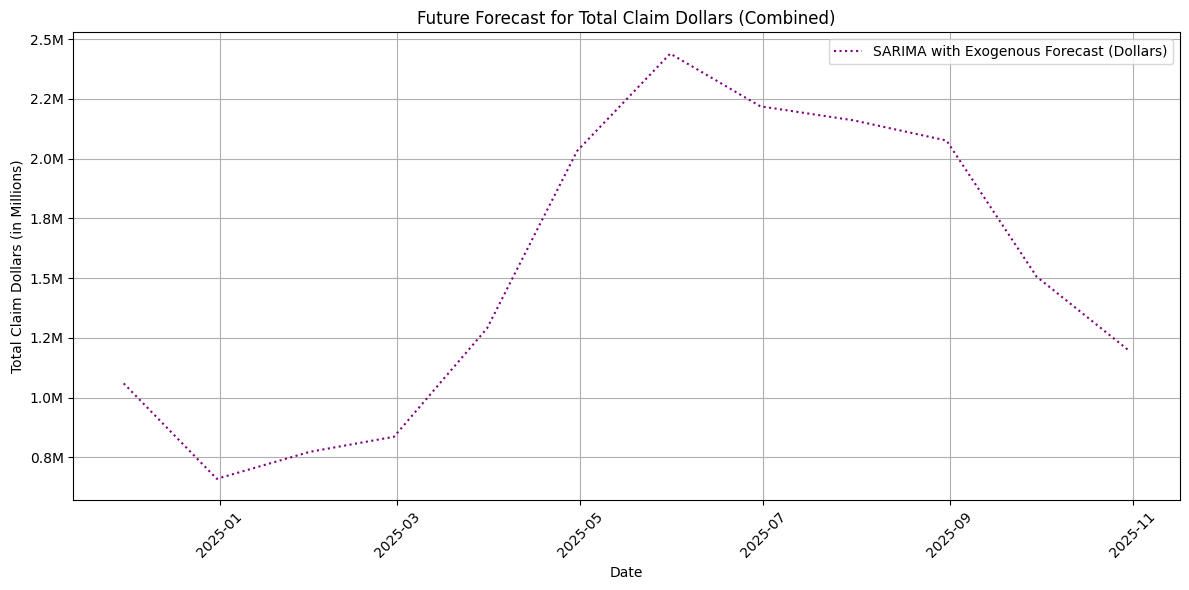

In [112]:
# plot graph for future forecast combined


# Plot future forecasts
plt.figure(figsize=(12, 6))

# Plot SARIMA with exogenous variables forecast
plt.plot(future_forecast_df_combined['Date'], future_forecast_df_combined['Forecasted Total Claim Dollars'], label='SARIMA with Exogenous Forecast (Dollars)', color='purple', linestyle=':')

plt.title('Future Forecast for Total Claim Dollars (Combined)')
plt.xlabel('Date')
plt.ylabel('Total Claim Dollars (in Millions)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

# Format y-axis
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:.1f}M'))


plt.tight_layout()
plt.show()


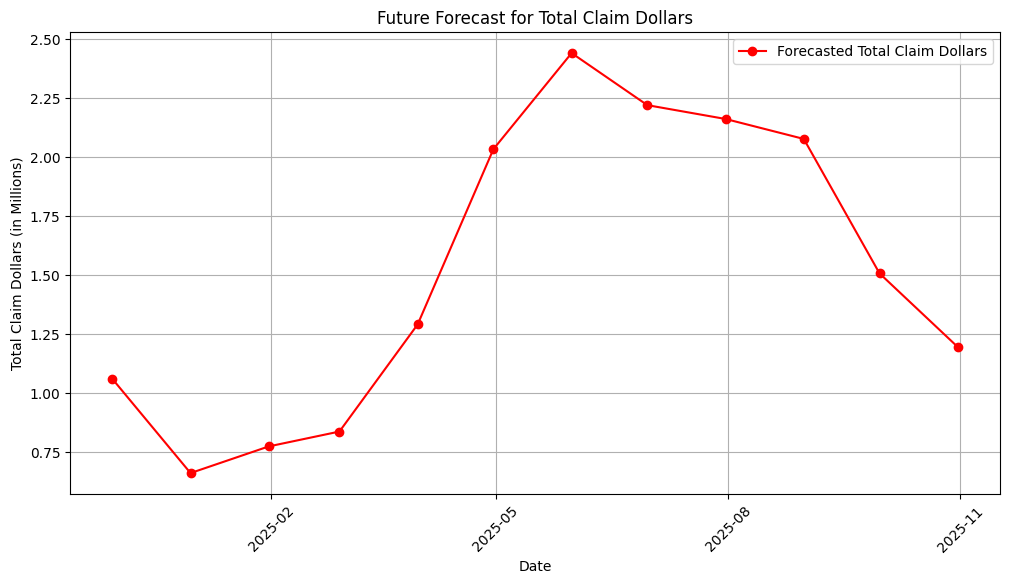

In [113]:
# Correcting the x-axis formatting for better readability
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))
plt.plot(future_forecast_df_combined["Date"], future_forecast_df_combined["Forecasted Total Claim Dollars"], marker='o', linestyle='-', color='red', label="Forecasted Total Claim Dollars")

plt.title("Future Forecast for Total Claim Dollars")
plt.xlabel("Date")
plt.ylabel("Total Claim Dollars (in Millions)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()


# Improve x-axis date formatting
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Show tick every 3 months
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))  # Format as Year-Month



plt.show()


<ipython-input-114-35d579aab744>:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=start_forecast_date, periods=12, freq='M')


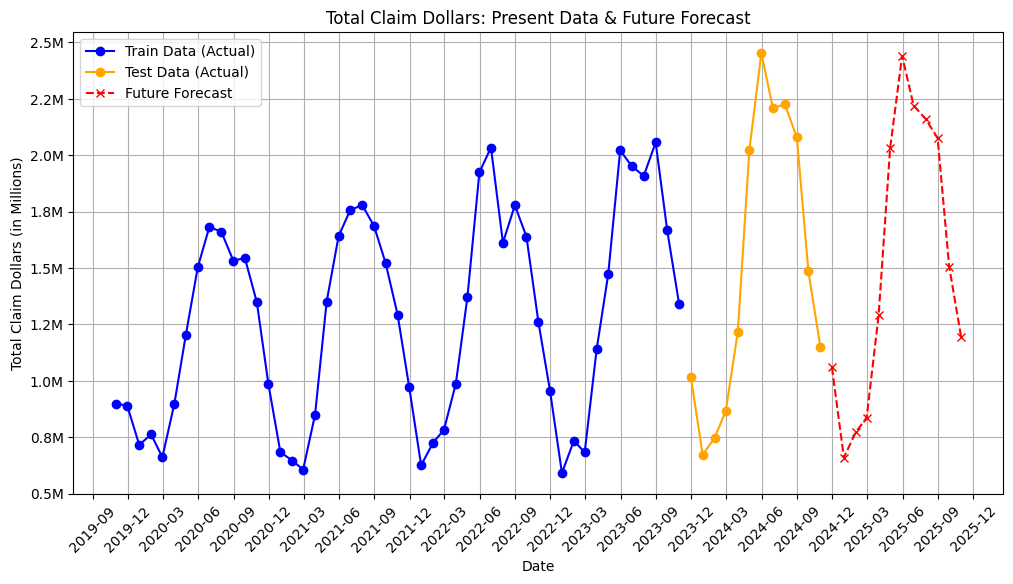

In [114]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

# Ensure forecast starts from Nov 2024
start_forecast_date = test["Failure Date"].max() + pd.DateOffset(months=1)
future_dates = pd.date_range(start=start_forecast_date, periods=12, freq='M')

# Update forecast DataFrame to ensure correct alignment
future_forecast_df_combined["Date"] = future_dates

# Plot Present Data (Train + Test) and Future Forecasts
plt.figure(figsize=(12, 6))

# Plot Train Data
plt.plot(train["Failure Date"], y_train / 1e6, marker='o', linestyle='-', color='blue', label="Train Data (Actual)")

# Plot Test Data
plt.plot(test["Failure Date"], y_test / 1e6, marker='o', linestyle='-', color='orange', label="Test Data (Actual)")

# Plot Future Forecast (Starting from Nov 2024)
plt.plot(future_forecast_df_combined["Date"], future_forecast_df_combined["Forecasted Total Claim Dollars"],
         marker='x', linestyle='--', color='red', label="Future Forecast")

# Title and labels
plt.title("Total Claim Dollars: Present Data & Future Forecast")
plt.xlabel("Date")
plt.ylabel("Total Claim Dollars (in Millions)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

# Format y-axis to show values in millions
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:.1f}M'))

# Improve x-axis date formatting
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.show()


In [115]:
# Check if y_test and test["Failure Date"] have the same length
print(f"Length of y_test: {len(y_test)}")
print(f"Length of test data: {len(test)}")

# If the lengths don't match, you may need to adjust y_test or test to align them.


Length of y_test: 12
Length of test data: 12


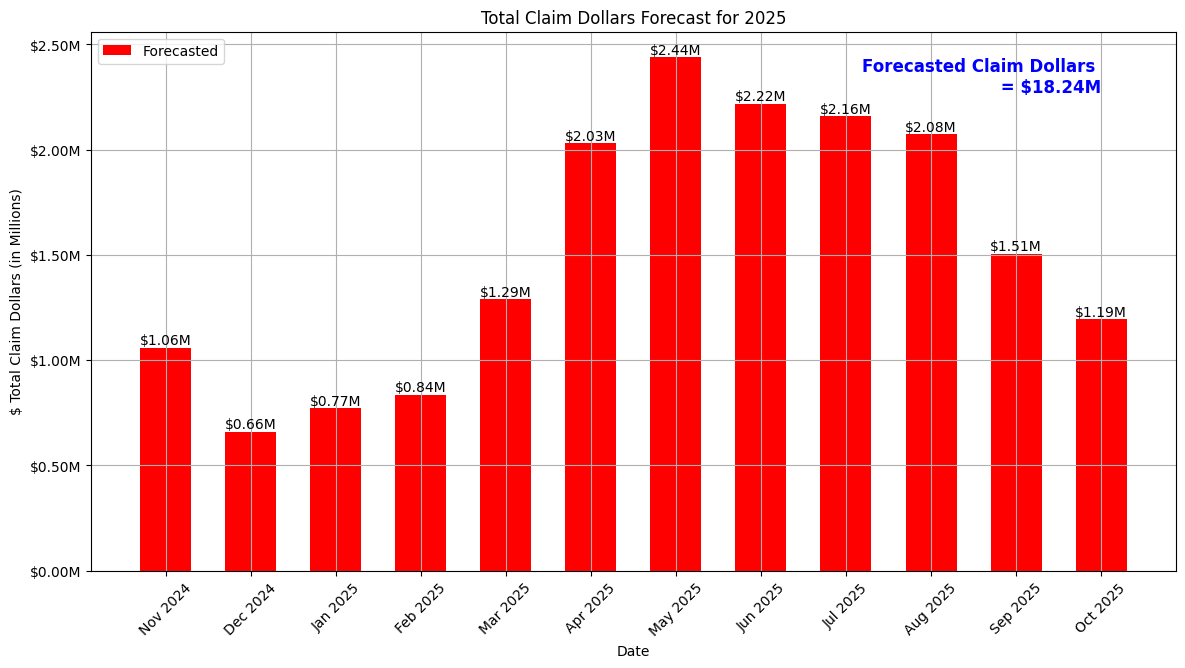

In [120]:
import matplotlib.ticker as ticker

# Plot Forecast for 2025 with currency on y-axis and value labels
plt.figure(figsize=(14, 7))

# Extract forecasted data for 2025
future_2025 = future_forecast_df_combined

# Create bar chart
x_labels_future = future_2025["Date"].dt.strftime('%b %Y')  # Convert date to "Jan 2025" format
x_future = np.arange(len(x_labels_future))

bars_future = plt.bar(x_future, future_2025["Forecasted Total Claim Dollars"],
                      width=0.6, color="red", label="Forecasted")

# Add value labels with currency symbol
for bar in bars_future:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'${bar.get_height():,.2f}M', ha='center', va='bottom', fontsize=10)

# Calculate total forecasted amount
total_forecasted = future_2025["Forecasted Total Claim Dollars"].sum()

# Get max y-axis value for proper placement
y_max = future_2025["Forecasted Total Claim Dollars"].max()

# Place total forecasted text on the **top-right** just below the legend
plt.text(len(x_labels_future) - 1, y_max * 1,
         f'Forecasted Claim Dollars \n = ${total_forecasted:,.2f}M',
         ha='right', va='top', fontsize=12, fontweight='bold', color='blue')

plt.xticks(ticks=x_future, labels=x_labels_future, rotation=45)
plt.title("Total Claim Dollars Forecast for 2025")
plt.xlabel("Date")
plt.ylabel("$ Total Claim Dollars (in Millions)")  # Currency symbol on the left
plt.legend()
plt.grid(True)

# Format y-axis as currency
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.2f}M'))

plt.show()


<ipython-input-127-932be9960548>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=model_names, y=rmse_values, palette="coolwarm")


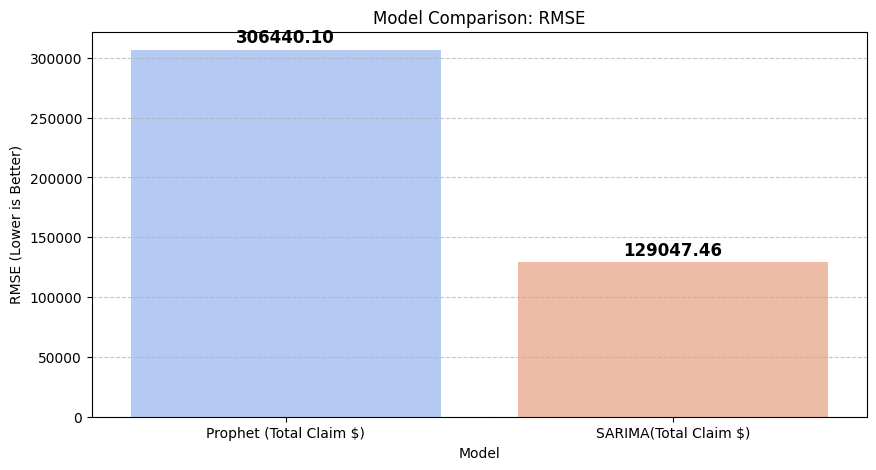

In [127]:
import seaborn as sns

# Compare RMSE, MSE, R-Squared across different models
model_names = [ 'Prophet (Total Claim $)','SARIMA(Total Claim $)']
rmse_values = [ rmse_dollars_prophet, rmse]
r2_values = [ r2_dollars_prophet, r2]


# Create RMSE comparison bar chart with horizontal bars and value labels
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=model_names, y=rmse_values, palette="coolwarm")

# Add value labels to bars
for i, v in enumerate(rmse_values):
    ax.text(i, v + 0.02 * max(rmse_values), f"{v:.2f}", ha='center', fontsize=12, fontweight='bold')

# Formatting
plt.ylabel("RMSE (Lower is Better)")
plt.xlabel("Model")
plt.title("Model Comparison: RMSE")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


<ipython-input-128-0f193fa43bd8>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=model_names, y=rmse_values_million, palette="coolwarm")


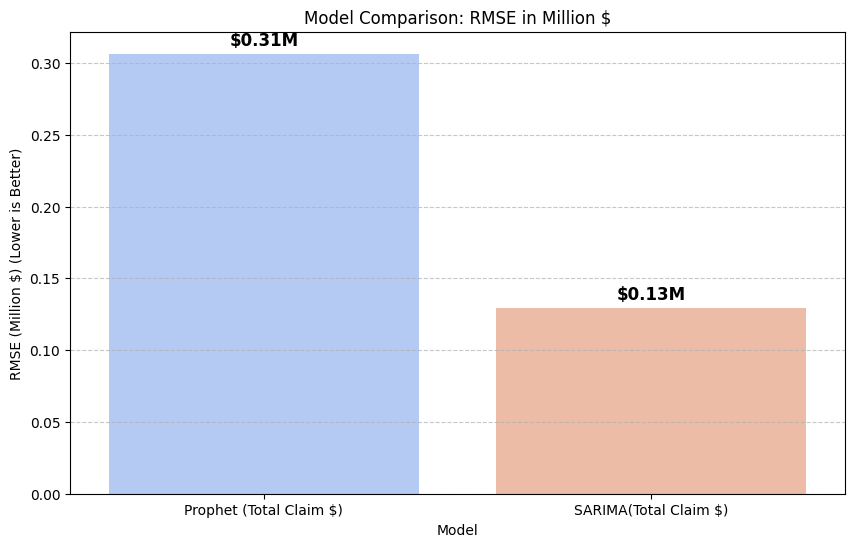

In [128]:
# Convert RMSE values to millions
rmse_values_million = [v / 1e6 for v in rmse_values]

# Create RMSE comparison bar chart with vertical bars and values in millions
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=model_names, y=rmse_values_million, palette="coolwarm")

# Add value labels in millions on top of bars
for index, value in enumerate(rmse_values_million):
    ax.text(index, value + 0.02 * max(rmse_values_million), f"${value:.2f}M", ha='center', fontsize=12, fontweight='bold')

# Formatting
plt.ylabel("RMSE (Million $) (Lower is Better)")
plt.xlabel("Model")
plt.title("Model Comparison: RMSE in Million $")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


<ipython-input-130-ee269a963240>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=model_names, y=r2_values, palette="coolwarm")


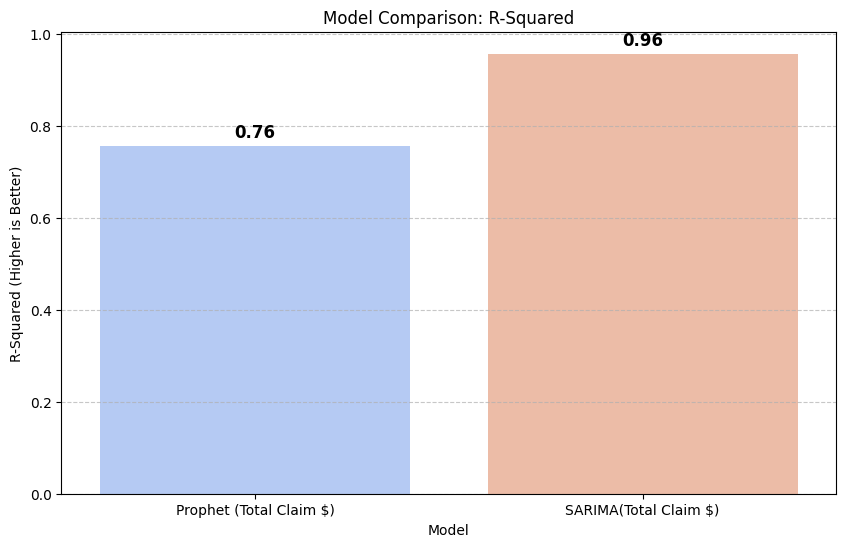

In [130]:
# Create R-Squared comparison bar chart with vertical bars and value labels

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=model_names, y=r2_values, palette="coolwarm")

# Add value labels on top of bars
for index, value in enumerate(r2_values):
    ax.text(index, value + 0.02 * max(r2_values), f"{value:.2f}", ha='center', fontsize=12, fontweight='bold')

# Formatting
plt.ylabel("R-Squared (Higher is Better)")
plt.xlabel("Model")
plt.title("Model Comparison: R-Squared")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


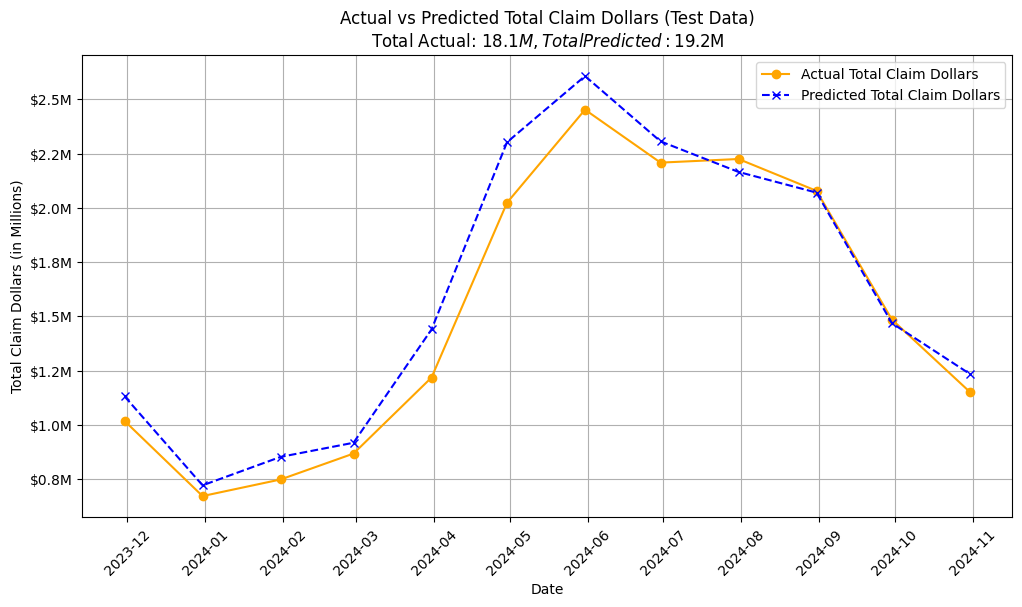

In [133]:
# plot actual vs predicted on test data, keep currency symbol in y axis, and show total values of actual vs predicted

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates


# Function to format currency with millions
def currency_millions(x, pos):
    return f'${x:.1f}M'

plt.figure(figsize=(12, 6))

# Plot Actual vs Predicted for Test Data
plt.plot(actual_vs_predicted_df["Date"], actual_vs_predicted_df['Actual Total Claim Dollars'], marker='o', linestyle='-', color='orange', label="Actual Total Claim Dollars")
plt.plot(actual_vs_predicted_df["Date"], actual_vs_predicted_df['Predicted Total Claim Dollars'], marker='x', linestyle='--', color='blue', label="Predicted Total Claim Dollars")


# Calculate and display total actual and predicted values
total_actual = actual_vs_predicted_df['Actual Total Claim Dollars'].sum()
total_predicted = actual_vs_predicted_df['Predicted Total Claim Dollars'].sum()

plt.title(f"Actual vs Predicted Total Claim Dollars (Test Data)\nTotal Actual: ${total_actual:.1f}M, Total Predicted: ${total_predicted:.1f}M")
plt.xlabel("Date")
plt.ylabel("Total Claim Dollars (in Millions)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

# Format y-axis to show currency with millions
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(currency_millions))

# Improve x-axis date formatting (optional, adjust interval as needed)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # Show tick every 3 months
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))  # Format as Year-Month


plt.show()


In [138]:
print(future_2025["Forecasted Total Claim Dollars"].describe())  # Check min, max, and mean values


count    12.000000
mean      1.520298
std       0.636227
min       0.659802
25%       1.003351
50%       1.397904
75%       2.096750
max       2.439435
Name: Forecasted Total Claim Dollars, dtype: float64
